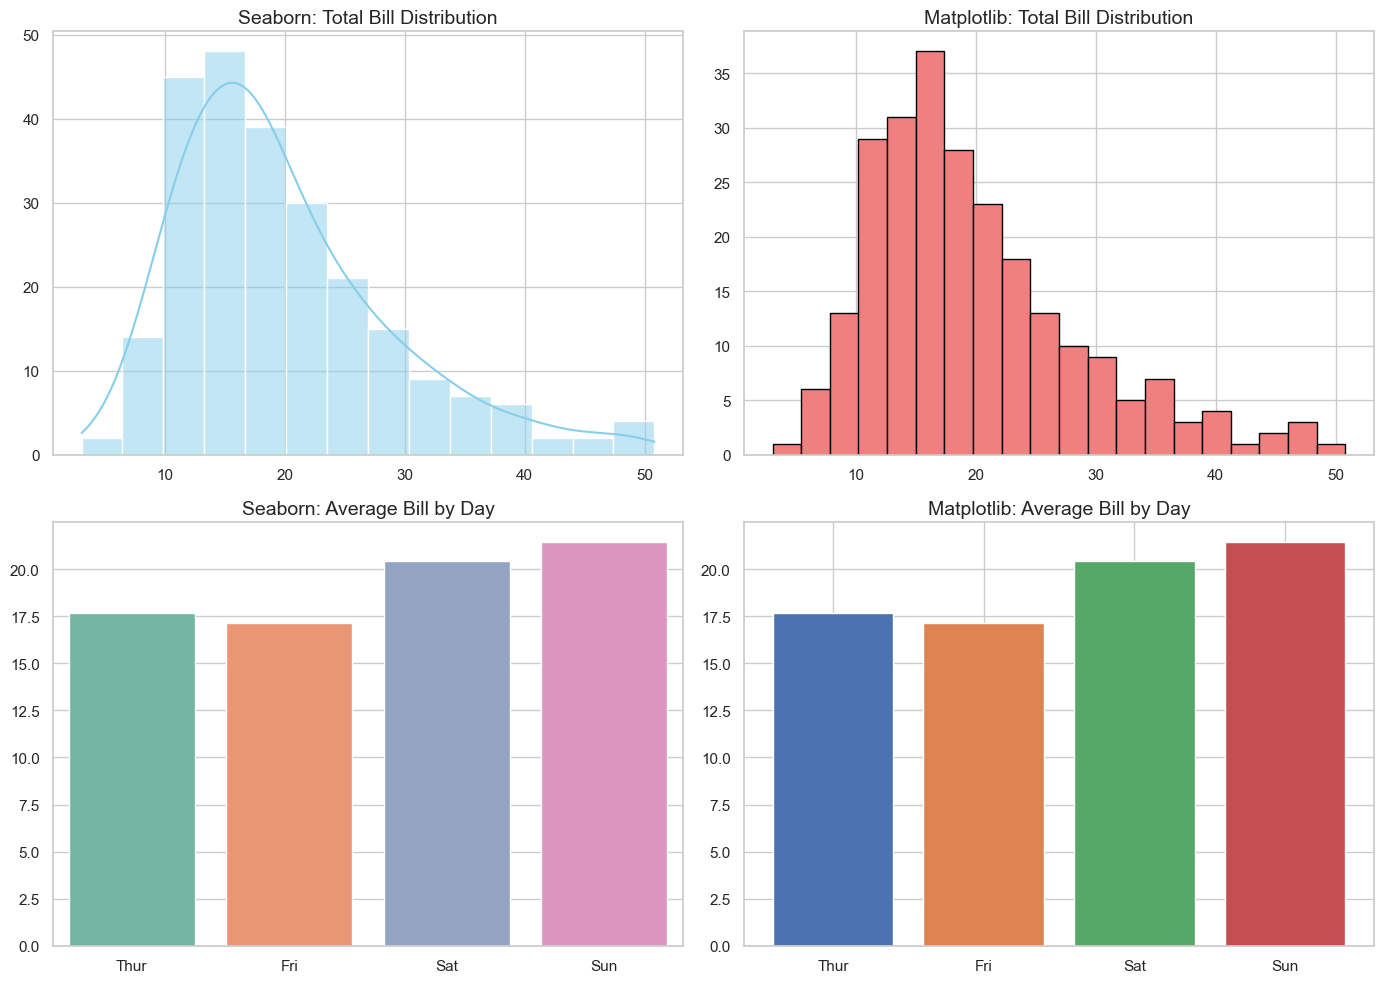

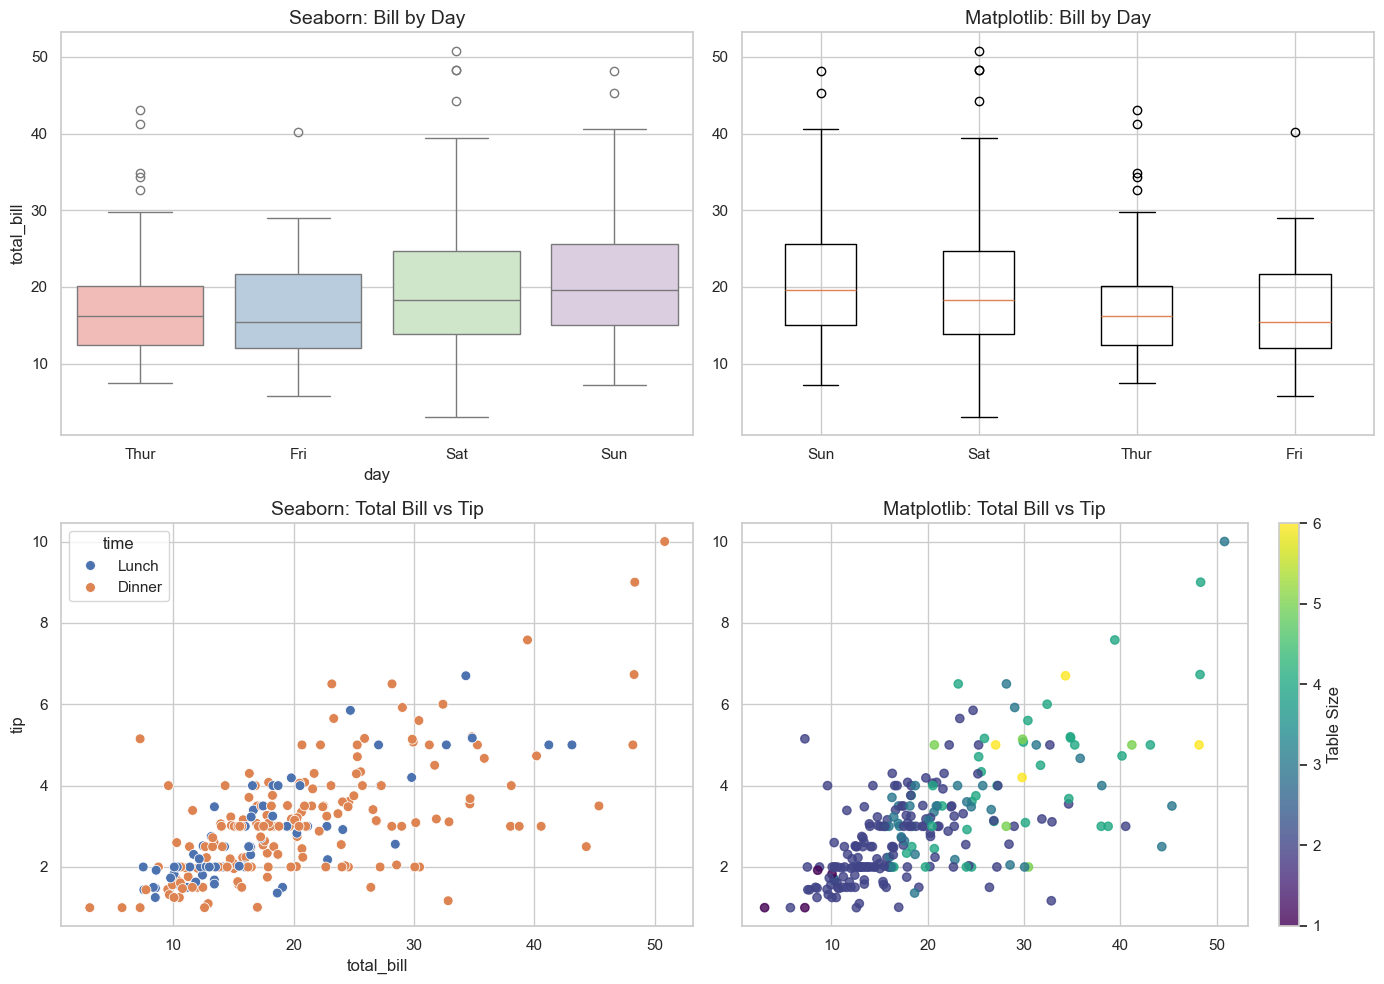

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Global configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 12})

# Load and process data
tips = sns.load_dataset("tips")
avg_bill_by_day = tips.groupby("day", observed=False)["total_bill"].mean()

# --- Figure 1: Histograms & Bar Charts ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograms
sns.histplot(data=tips, x="total_bill", kde=True, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Seaborn: Total Bill Distribution")

axes[0, 1].hist(tips["total_bill"], bins=20, color="lightcoral", edgecolor="black")
axes[0, 1].set_title("Matplotlib: Total Bill Distribution")

# Bar Charts (Fixed Warning)
sns.barplot(data=tips, x="day", y="total_bill", hue="day", legend=False, errorbar=None, palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("Seaborn: Average Bill by Day")

axes[1, 1].bar(avg_bill_by_day.index, avg_bill_by_day.values, color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
axes[1, 1].set_title("Matplotlib: Average Bill by Day")

for ax in axes.flat:
    ax.set(xlabel="", ylabel="")
plt.tight_layout()
plt.show()

# --- Figure 2: Box Plots & Scatter Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box Plots 
sns.boxplot(data=tips, x="day", y="total_bill", hue="day", legend=False, palette="Pastel1", ax=axes[0, 0])
axes[0, 0].set_title("Seaborn: Bill by Day")

days = tips["day"].unique()
axes[0, 1].boxplot([tips[tips["day"] == d]["total_bill"] for d in days], tick_labels=days)
axes[0, 1].set_title("Matplotlib: Bill by Day")

# Scatter Plots
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", palette="deep", s=50, ax=axes[1, 0])
axes[1, 0].set_title("Seaborn: Total Bill vs Tip")

scatter = axes[1, 1].scatter(tips["total_bill"], tips["tip"], c=tips["size"], cmap="viridis", alpha=0.8)
axes[1, 1].set_title("Matplotlib: Total Bill vs Tip")
fig.colorbar(scatter, ax=axes[1, 1], label="Table Size")

plt.tight_layout()
plt.show()

